In [30]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2' 
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,Dense,Dropout,Flatten
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report

/Users/shouryarghyapatra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 608.0 kB/s eta 0:00:0000:0100:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 360.8 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 498.6 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 525.2 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_csv("/Users/shouryarghyapatra/Downloads/complaints_processed.csv")

In [6]:
df.drop(columns='Unnamed: 0',axis=1,inplace=True)

In [7]:
df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
162416,debt_collection,name
162417,credit_card,name
162418,debt_collection,name
162419,credit_card,name


In [8]:
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [9]:
df.tail(10)

,product,narrative
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,debt_collection,name
162416,debt_collection,name
162417,credit_card,name
162418,debt_collection,name
162419,credit_card,name
162420,credit_reporting,name


In [10]:
df=df[df['narrative']!='name']
df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
162410,credit_reporting,zales comenity bank closed sold account report...
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162415 entries, 0 to 162414
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162415 non-null  object
 1   narrative  162405 non-null  object
dtypes: object(2)
memory usage: 3.7+ MB


In [12]:
df.describe(include='O')

,product,narrative
count,162415,162405
unique,5,124471
top,credit_reporting,victim identity notified collection creditor s...
freq,91178,739


In [13]:
df.duplicated().sum()

37739

In [14]:
df.drop_duplicates(inplace=True)

/var/folders/3v/3_zpq82x2_q18c70l85bxv600000gn/T/ipykernel_79462/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [15]:
df.isna().sum()

product      0
narrative    3
dtype: int64

In [16]:
df.dropna(subset=['narrative'],inplace=True)

/var/folders/3v/3_zpq82x2_q18c70l85bxv600000gn/T/ipykernel_79462/791919695.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['narrative'],inplace=True)


In [17]:
df.reset_index(drop=True,inplace=True)

In [18]:
df['product'].unique()


array(['credit_card', 'retail_banking', 'credit_reporting',
       'mortgages_and_loans', 'debt_collection'], dtype=object)

In [19]:
len(df['product'].unique())

5

In [20]:
df1=df['product'].value_counts()
df1

product
credit_reporting       56302
debt_collection        21116
mortgages_and_loans    18759
credit_card            15023
retail_banking         13473
Name: count, dtype: int64

Text(0.5, 1.0, 'Product Value Count')

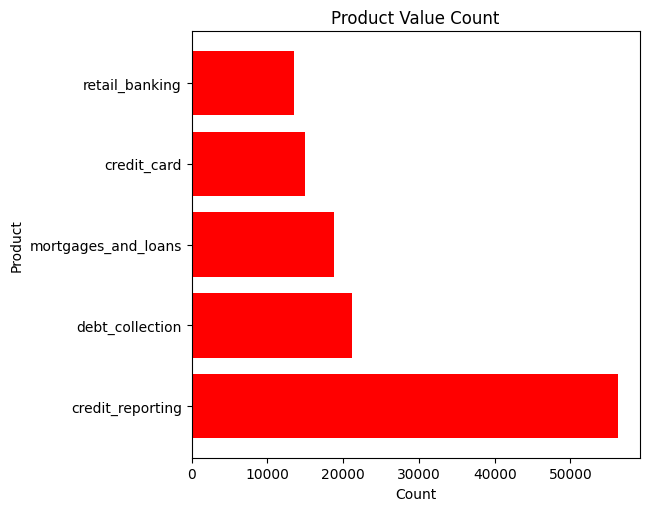

In [21]:
plt.barh(df1.index,df1.values,color='r')
plt.tight_layout()
plt.xlabel('Count')
plt.ylabel('Product')
plt.title('Product Value Count')

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
encoder=LabelEncoder()
df['product']=encoder.fit_transform(df['product'])


/var/folders/3v/3_zpq82x2_q18c70l85bxv600000gn/T/ipykernel_79462/1342104379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product']=encoder.fit_transform(df['product'])


In [26]:
import re

In [27]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\n',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text

df['narrative']=df['narrative'].apply(clean_text)


/var/folders/3v/3_zpq82x2_q18c70l85bxv600000gn/T/ipykernel_79462/1385395149.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['narrative']=df['narrative'].apply(clean_text)


In [28]:
df

,product,narrative
0,0,purchase order day shipping amount receive pro...
1,0,forwarded message date tue subject please inve...
2,4,forwarded message cc sent friday pdt subject f...
3,1,payment history missing credit report speciali...
4,1,payment history missing credit report made mis...
...,...,...
124668,1,zales comenity bank closed sold account report...
124669,4,zelle suspended account without cause banking ...
124670,2,zero contact made debt supposedly resolved fou...
124671,3,zillow home loan nmls nmls actual quote provid...


In [31]:
x=df['narrative']
y=df['product']
num_classes=len(np.unique(y))
num_classes
5
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,stratify=y,random_state=42)
x_train

6213      bank huntington pandemic first began placed lo...
59605     victim identity fraud filed police report told...
19493     hello making complaint clear path lending part...
106990    first time identity compromised please remove ...
91181     please check wire transfer sent fraud induce w...
                                ...                        
31630     earned reward jcp store toward future purchase...
35251     bank america prepaid card provided edd underem...
40894     disputed erroneous information credit bureau e...
39335     separated husband since renovate apartment you...
76157     student loan lates reporting late since refina...
Name: narrative, Length: 99738, dtype: object

In [32]:
x_test

115176    equifax website lifting credit freeze operatio...
40551     contacted company since paid car car paid say ...
50772     pulled credit alerted social security card get...
86203     received email capital one saying following ye...
80462     experian received letter stating investigate a...
                                ...                        
74099     identity compromised need following account in...
58057     submitted method verification letter dated cre...
65084     late notified several negative item credit rep...
54744     recently sent letter transunion dispute inaccu...
10137     conns blowing phone time day monday thru satur...
Name: narrative, Length: 24935, dtype: object

In [33]:
max_words=10000
max_len=200
tokenize=Tokenizer(num_words=max_words,oov_token='<OOV>')
tokenize.fit_on_texts(x_train)
x_train_seq=tokenize.texts_to_sequences(x_train)
x_test_seq=tokenize.texts_to_sequences(x_test)
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len,padding='post')
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len,padding='post')

In [34]:
ann=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')
])

In [35]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [36]:
ann.fit(x_train_pad,y_train,batch_size=32,epochs=10,validation_split=0.2)


Epoch 1/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.7406 - loss: 0.7269 - val_accuracy: 0.8426 - val_loss: 0.4595
Epoch 2/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - accuracy: 0.8631 - loss: 0.3881 - val_accuracy: 0.8358 - val_loss: 0.4848
Epoch 3/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.9058 - loss: 0.2647 - val_accuracy: 0.8212 - val_loss: 0.6130
Epoch 4/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.9363 - loss: 0.1774 - val_accuracy: 0.8272 - val_loss: 0.7018
Epoch 5/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.9564 - loss: 0.1241 - val_accuracy: 0.8213 - val_loss: 0.8470
Epoch 6/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - accuracy: 0.9671 - loss: 0.0950 - val_accuracy: 0.8204 - val_loss: 1.0149
Epoch 7/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - accuracy: 0.9707 - loss: 0.0843 - val_accuracy: 0.8194 - val_loss: 1.0624
Epoch 8/10
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.9753 -

In [37]:
y_pred_prob=ann.predict(x_test_pad)
y_pred_prob

780/780 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[3.2216377e-18, 1.0000000e+00, 2.1768964e-16, 3.8353771e-17,
        3.7179895e-22],
       [1.5837094e-07, 9.9950731e-01, 3.3020609e-04, 1.6236806e-04,
        6.1739053e-10],
       [2.5709254e-10, 9.9999988e-01, 1.2750719e-10, 5.9523856e-08,
        1.0743433e-13],
       ...,
       [8.2046396e-09, 9.9991083e-01, 8.8633664e-05, 5.8183218e-07,
        1.8053468e-10],
       [2.7627814e-10, 1.0000000e+00, 6.2989609e-09, 1.0233059e-12,
        2.8068061e-15],
       [4.5110905e-08, 9.9788588e-01, 6.7694671e-04, 1.2995282e-03,
        1.3767894e-04]], dtype=float32)

In [38]:
y_pred=np.argmax(y_pred_prob,axis=1)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [39]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[2171,  308,  102,   90,  334],
       [ 347, 9718,  738,  380,   77],
       [ 152,  752, 3057,  209,   53],
       [ 105,  408,  146, 2967,  126],
       [ 258,   79,   43,   56, 2259]])

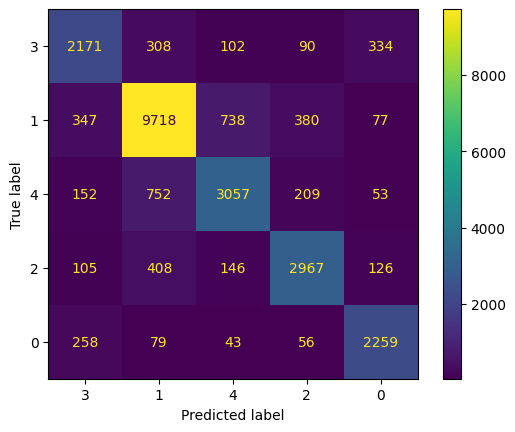

In [40]:
lab=[3,1,4,2,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [41]:
score=accuracy_score(y_test,y_pred)*100
score

80.89833567274914

In [42]:
report=classification_report(y_test,y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.72      0.72      0.72      3005
           1       0.86      0.86      0.86     11260
           2       0.75      0.72      0.74      4223
           3       0.80      0.79      0.80      3752
           4       0.79      0.84      0.81      2695

    accuracy                           0.81     24935
   macro avg       0.78      0.79      0.79     24935
weighted avg       0.81      0.81      0.81     24935

